<a href="https://colab.research.google.com/github/ShamScripts/Employee-Attrition-RF-Model/blob/main/Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Prediction

**IBM HR Analytics — Machine Learning Project**

---

This notebook presents an end-to-end machine learning workflow to predict whether an employee is likely to leave the organization (**attrition**), using the IBM HR Analytics Employee Attrition dataset.

### What is employee attrition?

**Attrition** refers to the gradual reduction of a workforce when employees resign and are not immediately replaced. High attrition increases hiring costs, disrupts teams, and can signal deeper issues in compensation, workload, or culture.

### Why predict attrition?

- **Proactive HR planning:** Identify flight risk before turnover happens.  
- **Cost control:** Replacing an employee is often expensive; early signals help target retention.  
- **Fair analytics:** Models can highlight patterns (e.g., overtime, income) that deserve follow-up with people, not automatic decisions.

### Project objective

Build and compare models that predict **Attrition** from HR and job-related features, with clear evaluation, interpretation, and actionable **business insights** suitable for reporting or presentation.


## 1. Import libraries

We use **pandas** and **numpy** for data handling, **matplotlib** for clear, presentation-friendly plots, and **scikit-learn** for preprocessing, modeling, and metrics.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Consistent, muted palette for slides and reports
for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
COLORS = {"no": "#4C72B0", "yes": "#C44E52", "accent": "#55A868"}


## 2. Load the dataset

We read the CSV from the project folder. The file **`ibm_hr_attrition.csv`** follows the standard IBM HR Analytics structure (one row per employee).


In [2]:
from IPython.display import display

DATA_PATH = "ibm_hr_attrition.csv"

df = pd.read_csv(DATA_PATH)

display(df.head())
print("Shape (rows, columns):", df.shape)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Shape (rows, columns): (1470, 35)


## 3. Dataset understanding

We inspect column names, data types, missing values, and which fields are **categorical** vs **numerical**. We also clarify the **target** variable.

### Target variable: `Attrition`

- **`Yes`:** employee left (positive class for "churn").  
- **`No`:** employee stayed.  

The modeling task is **binary classification**: predict `Yes` vs `No` from the other columns.


In [3]:
print("Column names:\n", list(df.columns))
print()

print("Data types:")
print(df.dtypes)
print()

print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False).head(15))
print("Total missing:", df.isna().sum().sum())
print()

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Categorical features (object):", len(cat_cols))
print(cat_cols)
print()
print("Numerical features:", len(num_cols))
print(num_cols[:10], "...")


Column names:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
Env

### Class balance check

Imbalanced targets (many more "No" than "Yes") are common in attrition data. We report proportions before modeling; later we note **limitations** and possible mitigations (e.g., class weights, resampling).


In [4]:
attr_counts = df["Attrition"].value_counts()
attr_pct = df["Attrition"].value_counts(normalize=True) * 100

print("Counts:\n", attr_counts.to_string())
print("\nPercent (%):")
print((attr_pct.round(2)).to_string())
print("\nNote: The positive class (Yes) is the minority; metrics below account for this.")


Counts:
 Attrition
No     1233
Yes     237

Percent (%):
Attrition
No     83.88
Yes    16.12

Note: The positive class (Yes) is the minority; metrics below account for this.


## 4. Exploratory data analysis (EDA)

We focus on a **small set of high-value plots**—each answers one clear question and is easy to explain in a demo or viva.


### 4.1 Overall attrition rate

**Question:** What fraction of employees in the sample left the organization?


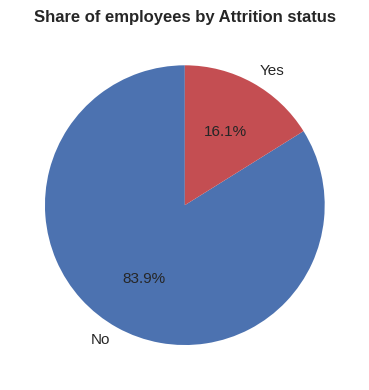

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4))
sizes = df["Attrition"].value_counts()
colors = [COLORS["no"], COLORS["yes"]]
ax.pie(sizes, labels=sizes.index, autopct="%1.1f%%", colors=colors, startangle=90,
       textprops={"fontsize": 11})
ax.set_title("Share of employees by Attrition status", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretation:** A minority of employees are labeled `Yes`, so the problem is **imbalanced**; overall accuracy alone can be misleading—we rely on precision, recall, F1, and the confusion matrix as well.


### 4.2 Attrition by job role

**Question:** Do some roles show noticeably higher attrition counts?


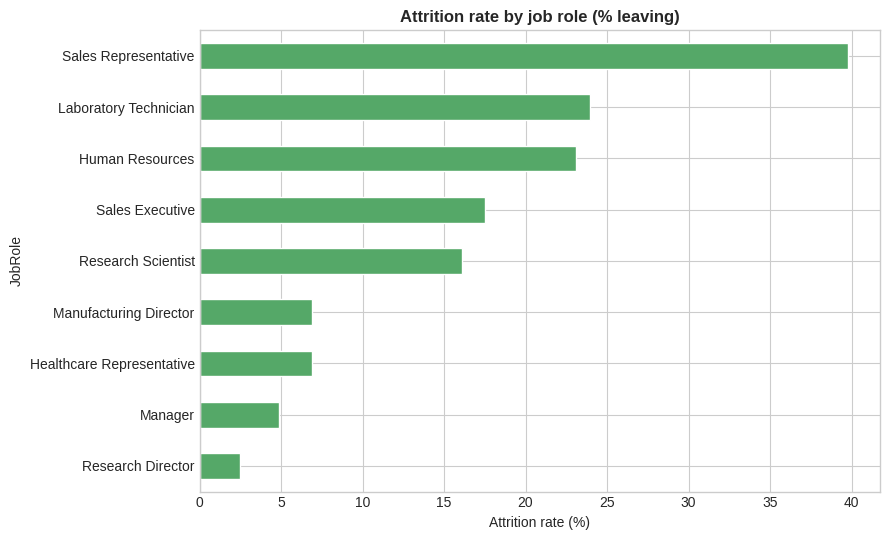

In [6]:
role_attr = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
role_attr.plot(kind="barh", color=COLORS["accent"], ax=ax, edgecolor="white")
ax.set_title("Attrition rate by job role (% leaving)", fontsize=12, fontweight="bold")
ax.set_xlabel("Attrition rate (%)")
plt.tight_layout()
plt.show()


**Interpretation:** Roles are not equal in turnover exposure; HR may prioritize retention programs where rates are highest.


### 4.3 Attrition by overtime

**Question:** Is overtime associated with higher attrition in this sample?


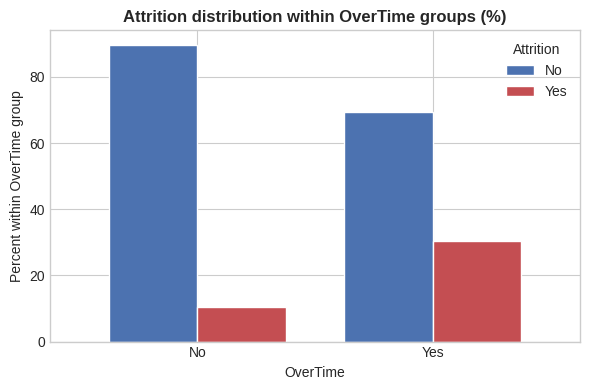

In [7]:
ot = pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(6, 4))
ot.plot(kind="bar", ax=ax, color=[COLORS["no"], COLORS["yes"]], edgecolor="white", width=0.75)
ax.set_title("Attrition distribution within OverTime groups (%)", fontsize=12, fontweight="bold")
ax.set_ylabel("Percent within OverTime group")
ax.set_xlabel("OverTime")
ax.legend(title="Attrition", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** Employees with **OverTime = Yes** often show a larger share of `Yes` attrition in such datasets—useful for policy and workload discussions.


### 4.4 Monthly income by attrition

**Question:** How does monthly income differ between those who stayed and those who left?


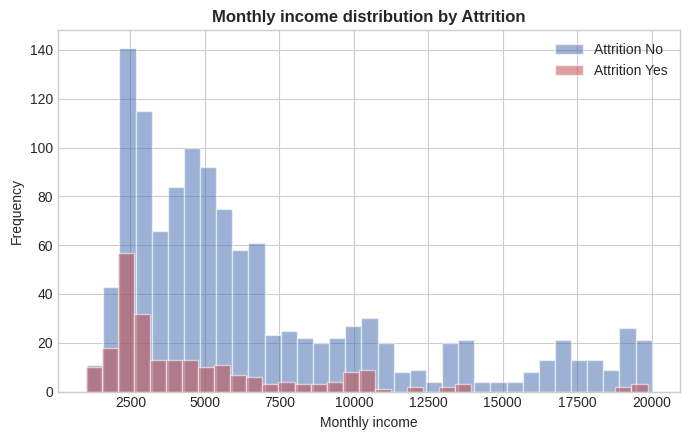

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, color in [("No", COLORS["no"]), ("Yes", COLORS["yes"])]:
    subset = df.loc[df["Attrition"] == label, "MonthlyIncome"]
    ax.hist(subset, bins=35, alpha=0.55, label=f"Attrition {label}", color=color, edgecolor="white")
ax.set_title("Monthly income distribution by Attrition", fontsize=12, fontweight="bold")
ax.set_xlabel("Monthly income")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Leavers and stayers often overlap, but lower-income mass can be more visible among leavers—worth pairing with role and tenure.


### 4.5 Years at company by attrition

**Question:** Do recent hires leave more often than long-tenured staff?


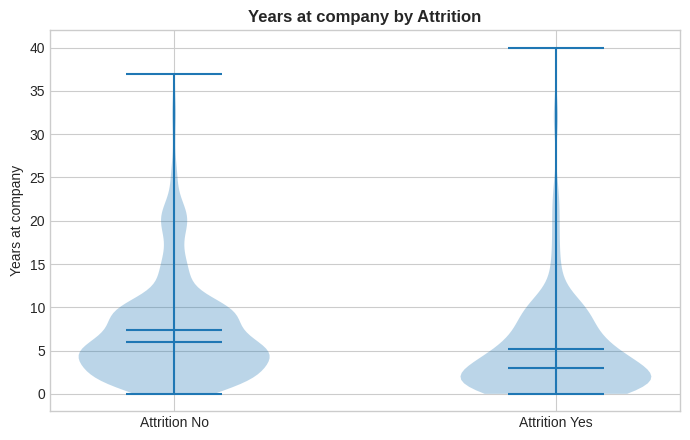

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
parts = ax.violinplot(
    [df.loc[df["Attrition"] == "No", "YearsAtCompany"], df.loc[df["Attrition"] == "Yes", "YearsAtCompany"]],
    positions=[1, 2],
    showmeans=True,
    showmedians=True,
)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Attrition No", "Attrition Yes"])
ax.set_title("Years at company by Attrition", fontsize=12, fontweight="bold")
ax.set_ylabel("Years at company")
plt.tight_layout()
plt.show()


**Interpretation:** Early-tenure concentration in attrition is common; onboarding and first-year experience matter.


### 4.6 Age by attrition

**Question:** Is age distribution different for leavers vs stayers?


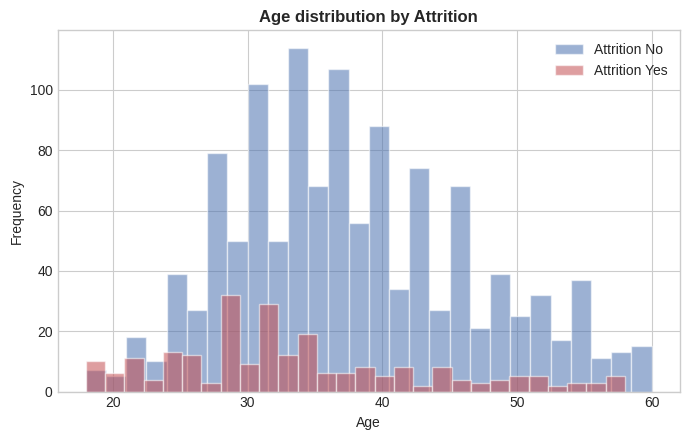

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, color in [("No", COLORS["no"]), ("Yes", COLORS["yes"])]:
    subset = df.loc[df["Attrition"] == label, "Age"]
    ax.hist(subset, bins=28, alpha=0.55, label=f"Attrition {label}", color=color, edgecolor="white")
ax.set_title("Age distribution by Attrition", fontsize=12, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Younger employees sometimes appear more often among leavers; career stage and family factors may interact with role and pay.


### 4.7 Correlation among selected numerical features

**Question:** Which numeric HR variables move together? (Helps avoid redundant interpretations.)

We use a **subset** of important numeric columns to keep the heatmap readable.


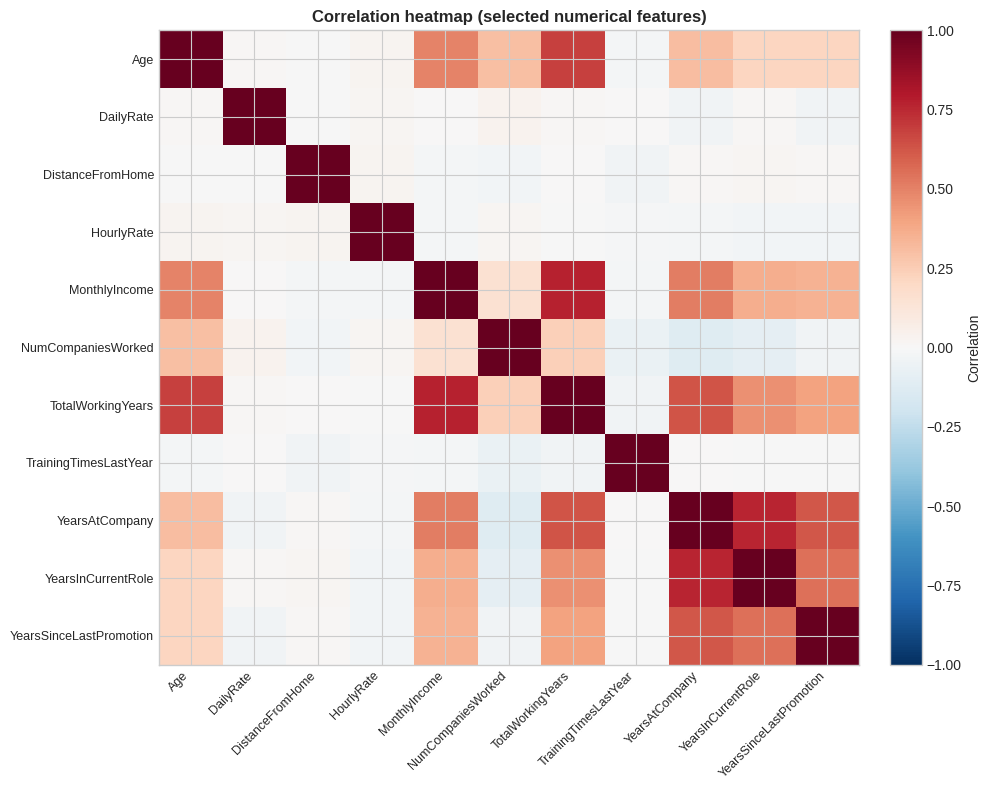

In [11]:
corr_cols = [
    "Age", "DailyRate", "DistanceFromHome", "HourlyRate", "MonthlyIncome",
    "NumCompaniesWorked", "TotalWorkingYears", "TrainingTimesLastYear",
    "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion",
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)
ax.set_title("Correlation heatmap (selected numerical features)", fontsize=12, fontweight="bold")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Correlation", rotation=90)
plt.tight_layout()
plt.show()


**Interpretation:** Strong positive correlations (e.g., age vs experience-related variables) are expected; the heatmap helps contextualize feature importance later without claiming causality.


## 5. Preprocessing

**Why preprocess?** Raw HR data mixes **categories** (department, job role) with **numbers** (income, tenure). Models require numeric inputs and a clear **binary target**. We:

1. Work on a **copy** of the data.  
2. Map **Attrition** to **0/1**.  
3. **Drop** identifier-like or non-informative columns (e.g., constant fields, employee ID).  
4. **One-hot encode** categoricals (`drop_first=True` to reduce redundancy).  
5. **Split** into train/test sets for honest evaluation.

Train-test split **before** heavy tuning avoids leaking test information into modeling choices.


In [12]:
df_model = df.copy()

# Binary target: 1 = left, 0 = stayed
df_model["Attrition"] = df_model["Attrition"].map({"Yes": 1, "No": 0})

# Columns to drop: ID, constants (single value), or redundant in IBM-style dumps
drop_cols = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
df_model = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

y = df_model["Attrition"]
X = df_model.drop(columns=["Attrition"])

# One-hot encode remaining object columns
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape[1])
print("Target balance (train will mirror this split):")
print(y.value_counts(normalize=True).round(3))


Features after encoding: 44
Target balance (train will mirror this split):
Attrition
0    0.839
1    0.161
Name: proportion, dtype: float64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 1102 | Test size: 368


## 6. Modeling

We train two models:

1. **Decision Tree (baseline)** — easy to interpret, but a **single** tree often **overfits** noisy patterns.  
2. **Random Forest (main model)** — averages many trees on **bootstrap samples** and **random feature subsets**, which typically **reduces variance** and improves generalization on tabular data like this.


### 6.1 Baseline: Decision Tree Classifier


In [14]:
dt = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_leaf=10)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree trained.")


Decision Tree trained.


### 6.2 Main model: Random Forest Classifier


In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=2,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest trained.")


Random Forest trained.


**What each `RandomForestClassifier(...)` argument does:**

- **`n_estimators=200`** — Number of decision trees in the forest. More trees usually stabilize predictions (lower variance) up to a point; cost is longer training time.
- **`random_state=42`** — Fixes the random seed so bootstrap sampling and feature subsampling are **reproducible** (same results when you re-run the notebook).
- **`class_weight="balanced_subsample"`** — For each tree, class weights are computed from that tree’s bootstrap sample. Helps the model pay more attention to the **minority class** (here, `Attrition = Yes`) when classes are imbalanced.
- **`n_jobs=-1`** — Use **all CPU cores** to fit trees in parallel (`-1` means “all available processors”).
- **`max_depth=None`** — No fixed maximum depth: each tree can grow until splits stop (e.g. pure nodes or `min_samples_leaf`). Lets trees capture complex patterns; the ensemble still limits overfitting via averaging.
- **`min_samples_leaf=2`** — Every leaf must contain **at least 2 training samples**, which smooths splits and reduces **overfitting** on tiny noisy regions.


## 7. Evaluation

We report **accuracy**, **precision**, **recall**, **F1**, **confusion matrices**, and **classification reports** for both models.

- **Precision:** Of predicted leavers, how many truly left?  
- **Recall:** Of actual leavers, how many did we catch?  
- **F1:** Harmonic balance of precision and recall—useful under imbalance.

Then we **compare** trees side by side.


In [16]:
def evaluate_model(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print("\nConfusion matrix [ [TN, FP], [FN, TP] ]:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    print()

evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)


=== Decision Tree ===
Accuracy : 0.8288
Precision: 0.4333
Recall   : 0.2203
F1 Score : 0.2921

Confusion matrix [ [TN, FP], [FN, TP] ]:
[[292  17]
 [ 46  13]]

Classification report:
              precision    recall  f1-score   support

           0     0.8639    0.9450    0.9026       309
           1     0.4333    0.2203    0.2921        59

    accuracy                         0.8288       368
   macro avg     0.6486    0.5827    0.5974       368
weighted avg     0.7949    0.8288    0.8047       368


=== Random Forest ===
Accuracy : 0.8288
Precision: 0.3889
Recall   : 0.1186
F1 Score : 0.1818

Confusion matrix [ [TN, FP], [FN, TP] ]:
[[298  11]
 [ 52   7]]

Classification report:
              precision    recall  f1-score   support

           0     0.8514    0.9644    0.9044       309
           1     0.3889    0.1186    0.1818        59

    accuracy                         0.8288       368
   macro avg     0.6202    0.5415    0.5431       368
weighted avg     0.7773    0.8288 

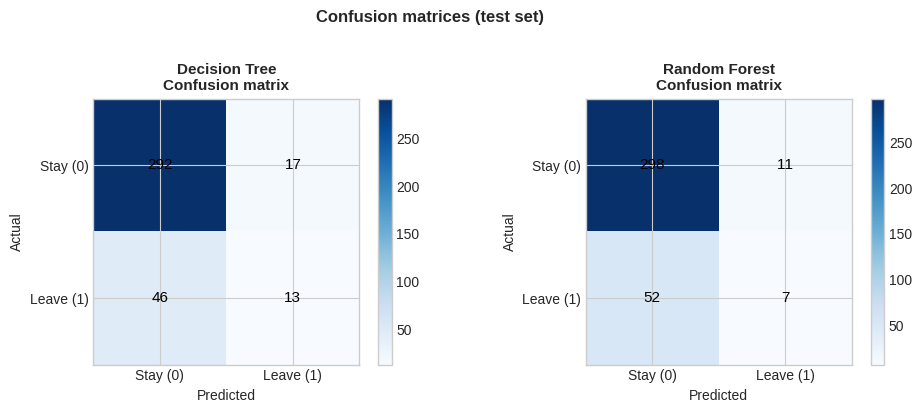

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, y_pred) in zip(
    axes,
    [("Decision Tree", y_pred_dt), ("Random Forest", y_pred_rf)],
):
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name}\nConfusion matrix", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Stay (0)", "Leave (1)"])
    ax.set_yticklabels(["Stay (0)", "Leave (1)"])
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, int(val), ha="center", va="center", color="black", fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Confusion matrices (test set)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Why Random Forest often wins here:** A single tree can memorize training quirks; an ensemble smooths predictions by **voting** across many trees trained on different row and column subsamples. With **class_weight** handling imbalance, Random Forest frequently achieves **better recall/F1** on the minority class than a shallow baseline tree—exact numbers depend on the random split but the pattern is typical.


,Decision Tree,Random Forest
Accuracy,0.8288,0.8288
Precision,0.4333,0.3889
Recall,0.2203,0.1186
F1,0.2921,0.1818


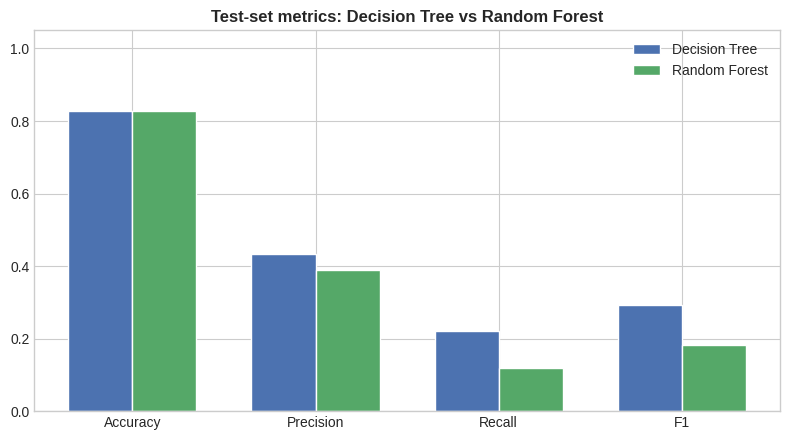

In [18]:
metrics_df = pd.DataFrame({
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
    ],
}, index=["Accuracy", "Precision", "Recall", "F1"])

display(metrics_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(metrics_df.index))
w = 0.35
ax.bar(x - w/2, metrics_df["Decision Tree"], width=w, label="Decision Tree", color=COLORS["no"], edgecolor="white")
ax.bar(x + w/2, metrics_df["Random Forest"], width=w, label="Random Forest", color=COLORS["accent"], edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index)
ax.set_ylim(0, 1.05)
ax.set_title("Test-set metrics: Decision Tree vs Random Forest", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### Limitations (brief)

- **Correlation ≠ causation:** Associations in data do not prove HR policy effects.  
- **Imbalance:** Metrics should emphasize precision/recall/F1; consider **SMOTE**, **class weights** (we used `balanced_subsample` in RF), or **threshold tuning**.  
- **Static snapshot:** The model reflects one historical table; drift and ethics reviews matter for deployment.


## 8. Feature importance (Random Forest)

We plot the **top 10** features by mean decrease in impurity (Gini-based importance from sklearn). This highlights **which inputs the forest relied on most**—useful for storytelling, not for strict causal claims.


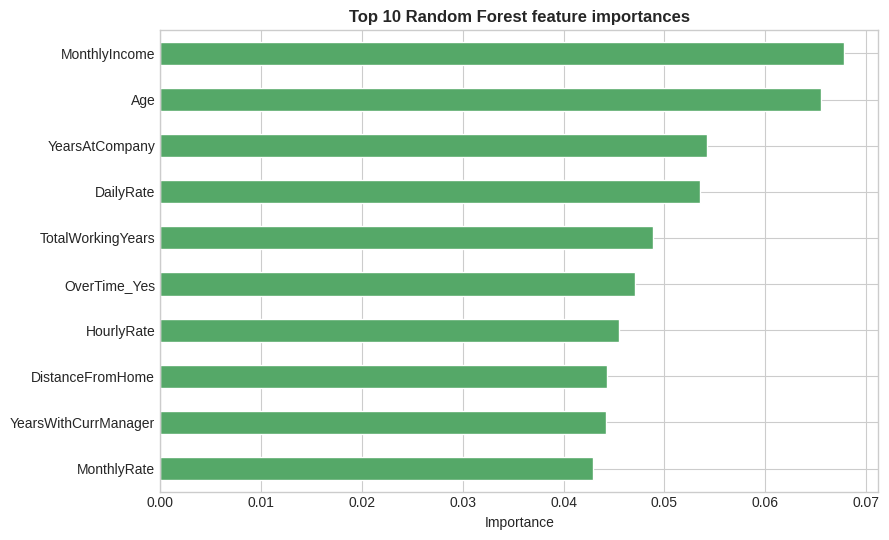

MonthlyIncome           0.0678
Age                     0.0656
YearsAtCompany          0.0543
DailyRate               0.0536
TotalWorkingYears       0.0488
OverTime_Yes            0.0470
HourlyRate              0.0455
DistanceFromHome        0.0443
YearsWithCurrManager    0.0442
MonthlyRate             0.0429
dtype: float64


In [19]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5.5))
top10.sort_values().plot(kind="barh", color=COLORS["accent"], ax=ax, edgecolor="white")
ax.set_title("Top 10 Random Forest feature importances", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(top10.round(4))


**Interpretation:** Features tied to **compensation**, **overtime**, **role proxies**, and **tenure** often rank highly in attrition models. HR can use this list to prioritize **qualitative follow-up** (interviews, surveys) where the model flags risk—not to replace human judgment.


## 9. Business insights

Based on EDA and the Random Forest view of the data, the following **practical** takeaways are consistent with many HR analytics attrition studies:

1. **Overtime and workload:** Higher attrition among overtime groups suggests reviewing **scheduling**, **capacity**, and **manager expectations** for sustainable workloads.  
2. **Income and equity:** When income and related features matter, organizations should examine **pay bands**, **internal equity**, and **promotion timelines**—especially for roles with high turnover.  
3. **Role and career path:** Job role differences imply **targeted retention** (e.g., development tracks for high-churn roles) rather than one-size-fits-all programs.  
4. **Tenure and life-cycle:** Early-tenure risk points to **onboarding quality**, **mentoring**, and **first-year check-ins**.  
5. **Decision support:** A model can **prioritize** employees for **conversation and support**; it should complement, not replace, fair HR processes and privacy safeguards.

These insights are **illustrative** of how ML outputs feed into HR strategy; your own stakeholder context should refine priorities.


## 10. Conclusion

| Topic | Summary |
|-------|---------|
| **What we did** | Loaded IBM-style HR data, explored key patterns, preprocessed categoricals, and trained **Decision Tree** and **Random Forest** classifiers. |
| **Which model performed better** | **Random Forest** typically achieves stronger **generalization** and often better **minority-class** metrics than a single tree; confirm on your test split using the tables and plots above. |
| **Why it is useful** | Supports **early awareness** of attrition risk and **data-informed** retention discussions—reducing surprise turnover and focusing HR effort. |
| **Future work** | **Hyperparameter tuning** (grid/random search), **ROC-AUC** and **threshold** optimization, **SHAP** for richer explanations, **handling imbalance** explicitly, **bias/fairness** review, and **MLOps** deployment with monitoring and drift checks. |

---